In [1]:
import json
import numpy as np
import os
import pandas as pd
import urllib.request
import urllib
import urllib.error
import urllib.parse
import urllib.response
from urllib.request import urlopen
# connect to poloniex's API
url = 'https://poloniex.com/public?command=returnChartData&currencyPair=USDT_ETH&start=1609430400&end=1625068800&period=900'

# parse json returned from the API to Pandas DF
openUrl = urlopen(url)
r = openUrl.read()
openUrl.close()
d = json.loads(r.decode())
df = pd.DataFrame(d)

original_columns=[u'close', u'date', u'high', u'low', u'open']
new_columns = ['Close','Timestamp','High','Low','Open']
df = df.loc[:,original_columns]
df.columns = new_columns
df.to_csv('ethereum2020.csv',index=None, encoding="utf-8")

In [2]:
df.head(5)

,Close,Timestamp,High,Low,Open
0,733.221603,1609430400,736.316124,732.500000,735.900000
1,733.578541,1609431300,735.024850,731.080000,733.014839
2,729.609244,1609432200,733.380032,729.609244,733.380032
3,727.742385,1609433100,730.277466,725.000000,730.277466
4,735.023420,1609434000,735.135135,727.000000,727.669628


In [3]:
hist = df.set_index('Timestamp')
hist.index = pd.to_datetime(hist.index, unit='s')
target_col = 'Close'
hist.head(5)

,Close,High,Low,Open
Timestamp,,,,
2020-12-31 16:00:00,733.221603,736.316124,732.500000,735.900000
2020-12-31 16:15:00,733.578541,735.024850,731.080000,733.014839
2020-12-31 16:30:00,729.609244,733.380032,729.609244,733.380032
2020-12-31 16:45:00,727.742385,730.277466,725.000000,730.277466
2020-12-31 17:00:00,735.023420,735.135135,727.000000,727.669628


In [4]:
def train_test_split(df, test_size=0.2):
    split_row = len(df) - int(test_size * len(df))
    train_data = df.iloc[:split_row]
    test_data = df.iloc[split_row:]
    return train_data, test_data

In [5]:
train, test = train_test_split(hist, test_size=0.2)

In [6]:
def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
    fig, ax = plt.subplots(1, figsize=(13, 7))
    ax.plot(line1, label=label1, linewidth=lw)
    ax.plot(line2, label=label2, linewidth=lw)
    ax.set_ylabel('price [USD]', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(loc='best', fontsize=16);

Using TensorFlow backend.


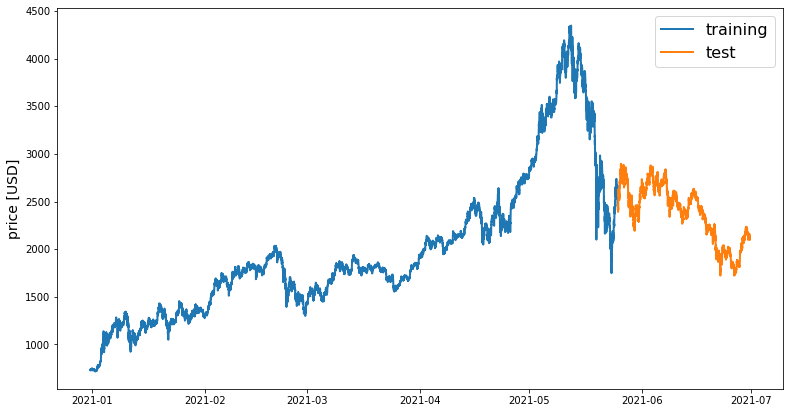

In [7]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error


line_plot(train[target_col], test[target_col], 'training', 'test', title='')

In [8]:
#Data pre-processing - Normalisation
def normalise_zero_base(df):
    return df / df.iloc[0] - 1

def normalise_min_max(df):
    return (df - df.min()) / (data.max() - df.min())



In [9]:
def extract_window_data(df, window_len=5, zero_base=True):
    window_data = []
    for idx in range(len(df) - window_len):
        tmp = df[idx: (idx + window_len)].copy()
        if zero_base:
            tmp = normalise_zero_base(tmp)
        window_data.append(tmp.values)
    return np.array(window_data)

In [10]:
def prepare_data(df, target_col, window_len=10, zero_base=True, test_size=0.2):
    train_data, test_data = train_test_split(df, test_size=test_size)
    X_train = extract_window_data(train_data, window_len, zero_base)
    X_test = extract_window_data(test_data, window_len, zero_base)
    y_train = train_data[target_col][window_len:].values
    y_test = test_data[target_col][window_len:].values
    if zero_base:
        y_train = y_train / train_data[target_col][:-window_len].values - 1
        y_test = y_test / test_data[target_col][:-window_len].values - 1

    return train_data, test_data, X_train, X_test, y_train, y_test

In [11]:
def build_lstm_model(input_data, output_size, neurons=100, activ_func='linear',
                     dropout=0.2, loss='mse', optimizer='adam'):
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))

    model.compile(loss=loss, optimizer=optimizer)
    return model

In [12]:
np.random.seed(42)
window_len = 5
test_size = 0.2
zero_base = True
lstm_neurons = 100
epochs = 20
batch_size = 32
loss = 'mse'
dropout = 0.2
optimizer = 'adam'

In [13]:
train, test, X_train, X_test, y_train, y_test = prepare_data(
    hist, target_col, window_len=window_len, zero_base=zero_base, test_size=test_size)

In [14]:
model = build_lstm_model(
    X_train, output_size=1, neurons=lstm_neurons, dropout=dropout, loss=loss,
    optimizer=optimizer)
history = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=1, shuffle=True)

Train on 13897 samples, validate on 3470 samples
Epoch 1/20
13897/13897 [==============================] - 20s 1ms/step - loss: 1.0010e-04 - val_loss: 4.9000e-05
Epoch 2/20
13897/13897 [==============================] - 15s 1ms/step - loss: 7.2180e-05 - val_loss: 4.4870e-05
Epoch 3/20
13897/13897 [==============================] - 16s 1ms/step - loss: 6.7791e-05 - val_loss: 4.5774e-05
Epoch 4/20
13897/13897 [==============================] - 12s 870us/step - loss: 6.7068e-05 - val_loss: 4.0859e-05
Epoch 5/20
13897/13897 [==============================] - 10s 731us/step - loss: 6.7113e-05 - val_loss: 4.2808e-05
Epoch 6/20
13897/13897 [==============================] - 14s 976us/step - loss: 6.6451e-05 - val_loss: 4.5040e-05
Epoch 7/20
13897/13897 [==============================] - 15s 1ms/step - loss: 6.6410e-05 - val_loss: 4.1674e-05
Epoch 8/20
13897/13897 [==============================] - 14s 1ms/step - loss: 6.5697e-05 - val_loss: 4.2734e-05
Epoch 9/20
13897/13897 [=================

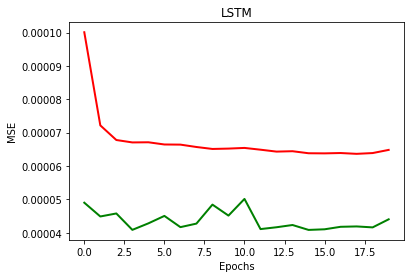

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],'r',linewidth=2, label='Train loss')
plt.plot(history.history['val_loss'], 'g',linewidth=2, label='Validation loss')
plt.title('LSTM')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

In [16]:
targets = test[target_col][window_len:]
preds = model.predict(X_test).squeeze()
MAE=mean_absolute_error(preds, y_test)
MAE

0.0048534793357808085

In [17]:
from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(preds, y_test)
MSE
import math
RMSE=math.sqrt(MSE)
RMSE

0.006634694834743299

In [18]:
from sklearn.metrics import r2_score
R2=r2_score(y_test, preds)
R2

0.7993667085830756

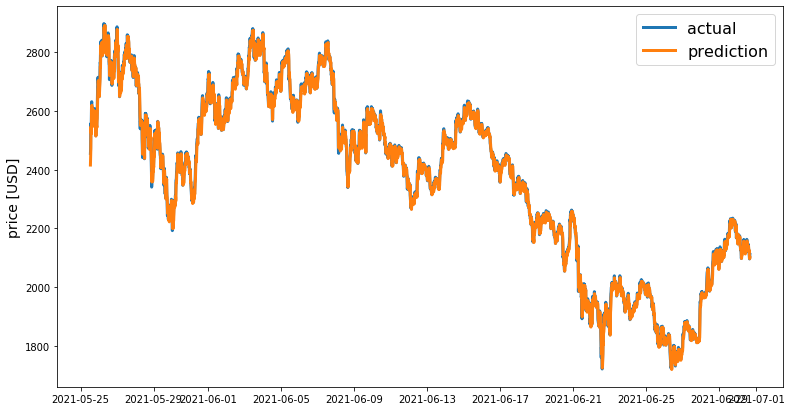

In [19]:
preds = test[target_col].values[:-window_len] * (preds + 1)
preds = pd.Series(index=targets.index, data=preds)
line_plot(targets, preds, 'actual', 'prediction', lw=3)

In [ ]:
#ETH, 15mins data with 17,377 datapoints
#lstm: testset=0.2; dropout=0.2
#results are RMSE=0.006634694834743299; R2=0.7993667085830756

In [ ]:
# NOW, TRY DAILY btc_withETH_price DATASET (4years)

df = pd.DataFrame(pd.read_csv('bitcoin2018to2021_withETH.csv'))
df.head(5)

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt

df['Date'] = pd.to_datetime(df.Date)
df.head()
hist = df.set_index('Date')
hist.index = pd.to_datetime(hist.index, unit='s')
target_col = 'Close'
hist.head(5)

,Open,High,Low,Close,Adj Close,Volume,ETH_Open,ETH_High,ETH_Low,ETH_Close
Date,,,,,,,,,,
2018-01-01,14112.2002,14112.20020,13154.70020,13657.20020,13657.20020,1.029120e+10,755.757019,782.530029,742.004028,772.640991
2018-01-02,13625.0000,15444.59961,13163.59961,14982.09961,14982.09961,1.684660e+10,772.346008,914.830017,772.346008,884.443970
2018-01-03,14978.2002,15572.79981,14844.50000,15201.00000,15201.00000,1.687190e+10,886.000000,974.471008,868.450989,962.719971
2018-01-04,15270.7002,15739.70020,14522.20020,15599.20020,15599.20020,2.178320e+10,961.713013,1045.079956,946.085999,980.921997
2018-01-05,15477.2002,17705.19922,15202.79981,17429.50000,17429.50000,2.384090e+10,975.750000,1075.390015,956.325012,997.719971


In [54]:
def train_test_split(df, test_size=0.15):
    split_row = len(df) - int(test_size * len(df))
    train_data = df.iloc[:split_row]
    test_data = df.iloc[split_row:]
    return train_data, test_data

In [55]:
train, test = train_test_split(hist, test_size=0.15)

In [56]:
def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
    fig, ax = plt.subplots(1, figsize=(13, 7))
    ax.plot(line1, label=label1, linewidth=lw)
    ax.plot(line2, label=label2, linewidth=lw)
    ax.set_ylabel('price [USD]', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(loc='best', fontsize=16);

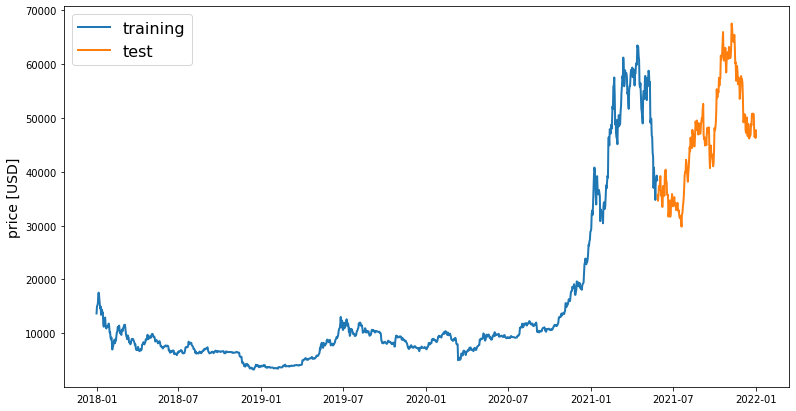

In [57]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

line_plot(train[target_col], test[target_col], 'training', 'test', title='')

In [58]:
def normalise_zero_base(df):
    return df / df.iloc[0] - 1

def normalise_min_max(df):
    return (df - df.min()) / (data.max() - df.min())

In [59]:
def extract_window_data(df, window_len=5, zero_base=True):
    window_data = []
    for idx in range(len(df) - window_len):
        tmp = df[idx: (idx + window_len)].copy()
        if zero_base:
            tmp = normalise_zero_base(tmp)
        window_data.append(tmp.values)
    return np.array(window_data)

In [69]:
def prepare_data(df, target_col, window_len=10, zero_base=True, test_size=0.15):
    train_data, test_data = train_test_split(df, test_size=test_size)
    X_train = extract_window_data(train_data, window_len, zero_base)
    X_test = extract_window_data(test_data, window_len, zero_base)
    y_train = train_data[target_col][window_len:].values
    y_test = test_data[target_col][window_len:].values
    if zero_base:
        y_train = y_train / train_data[target_col][:-window_len].values - 1
        y_test = y_test / test_data[target_col][:-window_len].values - 1

    return train_data, test_data, X_train, X_test, y_train, y_test

In [78]:
def build_lstm_model(input_data, output_size, neurons=100, activ_func='linear',
                     dropout=0.05, loss='mse', optimizer='adam'):
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))

    model.compile(loss=loss, optimizer=optimizer)
    return model

In [79]:
np.random.seed(42)
window_len = 5
test_size = 0.15
zero_base = True
lstm_neurons = 100
epochs = 20
batch_size = 32
loss = 'mse'
dropout = 0.05
optimizer = 'adam'

In [80]:
train, test, X_train, X_test, y_train, y_test = prepare_data(
    hist, target_col, window_len=window_len, zero_base=zero_base, test_size=test_size)

In [82]:
model = build_lstm_model(
    X_train, output_size=1, neurons=lstm_neurons, dropout=dropout, loss=loss,
    optimizer=optimizer)
history = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=1, shuffle=True)

Train on 1238 samples, validate on 214 samples
Epoch 1/20
1238/1238 [==============================] - 3s 3ms/step - loss: 0.0030 - val_loss: 0.0020
Epoch 2/20
1238/1238 [==============================] - 1s 775us/step - loss: 0.0021 - val_loss: 0.0017
Epoch 3/20
1238/1238 [==============================] - 1s 1ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 4/20
1238/1238 [==============================] - 1s 803us/step - loss: 0.0018 - val_loss: 0.0016
Epoch 5/20
1238/1238 [==============================] - 1s 1ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 6/20
1238/1238 [==============================] - 1s 1ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 7/20
1238/1238 [==============================] - 1s 875us/step - loss: 0.0017 - val_loss: 0.0015
Epoch 8/20
1238/1238 [==============================] - 1s 1ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 9/20
1238/1238 [==============================] - 1s 1ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 10/20
1238/1238 [======

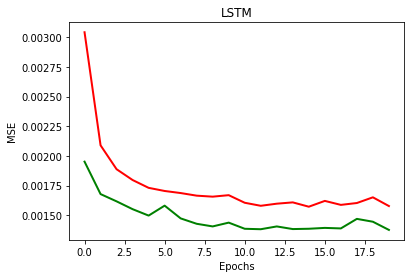

In [85]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],'r',linewidth=2, label='Train loss')
plt.plot(history.history['val_loss'], 'g',linewidth=2, label='Validation loss')
plt.title('LSTM')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

In [86]:
targets = test[target_col][window_len:]
preds = model.predict(X_test).squeeze()
MAE=mean_absolute_error(preds, y_test)
MAE

0.028056160724817928

In [87]:
from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(preds, y_test)
MSE
import math
RMSE=math.sqrt(MSE)
RMSE

0.03709864805345741

In [88]:
from sklearn.metrics import r2_score
R2=r2_score(y_test, preds)
R2

0.7715716053932102

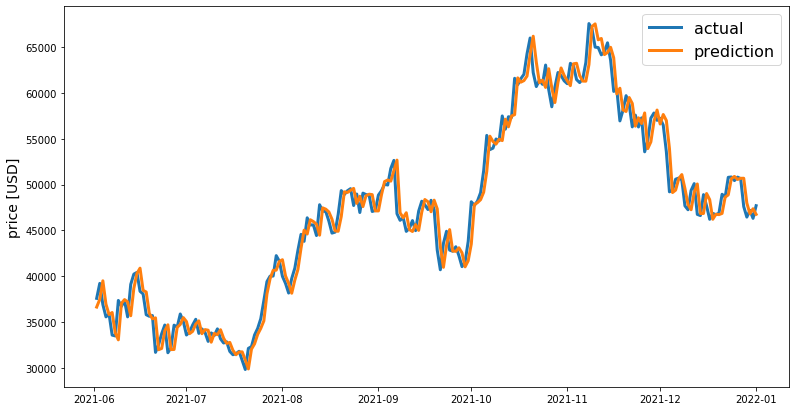

In [89]:
preds = test[target_col].values[:-window_len] * (preds + 1)
preds = pd.Series(index=targets.index, data=preds)
line_plot(targets, preds, 'actual', 'prediction', lw=3)

In [ ]:
#4-year,daily data with 1379 datapoints
#with more features: ETH price
#lstm: testset=0.15; dropout=0.05
#results are RMSE=0.03709864805345741; R2=0.7715716053932102